<img src="https://raw.githubusercontent.com/carubbi/MQ/main/notebooks/assets/imgs/UNIFOR_logo.png" width="400">
<br>
<b>
<font size="6" face="arial" color="blue">
    Graduação em Ciência da Computação
</font>
</b>
<br>
<b>
<font size="4" face="arial">
    Disciplina: Métodos Quantitativos em Computação
</font>
</b>

**Orientador: Prof. Me. Ricardo Carubbi** <br>
*Docente da Graduação e Pós-Graduação em Ciência de Dados e Inteligência Artificial*<br>
*Laboratório de Ciência de Dados e Inteligência Artificial*<br>
*Universidade de Fortaleza*<br>

Lattes: http://lattes.cnpq.br/5738786447903616 |
GitHub: https://github.com/carubbi/

[Unifor.br](https://unifor.br/) | [Instagram](https://www.instagram.com/uniforcomunica/?hl=pt-br) | [Facebook](https://www.facebook.com/uniforoficial/) | [Twitter](https://www.facebook.com/uniforoficial/)  | [LinkedIn](https://www.linkedin.com/school/university-of-fortaleza/?originalSubdomain=pt) | [TV Unifor](https://www.unifor.br/tv-unifor) | [G1/Ensinando e Aprendendo](https://g1.globo.com/ce/ceara/especial-publicitario/unifor/ensinando-e-aprendendo/)


# Resumo

## **Aula 6: Distribuições de frequências e visualização de dados**

Este notebook aplica ao **Palmer Penguins** os quatro ciclos da aula teórica: frequências para categorias, agrupamento de dados quantitativos, comparação de critérios para classes e escolha de representações. Cada ciclo começa com um caso reduzido verificável e avança para as observações disponíveis no conjunto completo.

Freedman–Diaconis e Scott aparecem somente como referências computacionais antecipadas. O intervalo interquartil e o desvio-padrão necessários à interpretação desses critérios serão estudados na Aula 7.

Nesta versão resolvida, as células de código e os registros interpretativos estão preenchidos e devem ser lidos em ordem.


## Objetivos de aplicação

Ao concluir a prática, você deverá ser capaz de:

1. calcular frequências absoluta, relativa e percentual com denominador explícito;
2. agrupar valores quantitativos em intervalos e conferir a soma das frequências;
3. comparar Sturges e largura fixa, registrando Freedman–Diaconis e Scott como referências computacionais;
4. produzir barras, histograma, linha e dispersão de acordo com o tipo das variáveis;
5. interpretar cada representação sem generalizar a composição do arquivo nem atribuir causalidade a associações visuais.


## Situação prática

A equipe já diagnosticou tipos, ausências e chaves do Palmer Penguins. Agora precisa resumir a composição das observações, examinar a distribuição da massa corporal e escolher representações compatíveis com categorias, intervalos quantitativos, datas e pares de medidas. Os denominadores e as ausências devem acompanhar cada resultado.


## Preparação instrumental dos dados

Execute as células na ordem. Complete somente os trechos indicados pelos comentários. Preserve o DataFrame bruto e use apenas valores válidos quando o denominador depender de uma variável com ausências.


In [1]:
# Importar as bibliotecas utilizadas na aula.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


In [2]:
# Carregar a versão bruta do Palmer Penguins.
arquivo_dados = "https://raw.githubusercontent.com/carubbi/MQ/main/data/raw/penguins_raw.csv"
penguins = pd.read_csv(arquivo_dados)
penguins.head()


,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A1,Yes,2007-11-11,39.1,18.7,181.0,3750.0,MALE,NaN,NaN,Not enough blood for isotopes.
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A2,Yes,2007-11-11,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454,NaN
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A1,Yes,2007-11-16,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302,NaN
3,PAL0708,4,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A2,Yes,2007-11-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult not sampled.
4,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A1,Yes,2007-11-16,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426,NaN


**Tabela 1 - Primeiras observações da versão bruta.** Cada linha corresponde a um pinguim registrado e cada coluna representa uma característica da coleta ou do animal. Fonte: Palmer Penguins.


In [3]:
# Reunir o inventário necessário às distribuições.
massas_validas = penguins["Body Mass (g)"].dropna()
inventario = pd.Series(
    {
        "observações": len(penguins),
        "espécies distintas": penguins["Species"].nunique(),
        "massas válidas": len(massas_validas),
        "massa mínima (g)": massas_validas.min(),
        "massa máxima (g)": massas_validas.max(),
    },
    name="Valor",
)
inventario.to_frame()


,Valor
observações,344.0
espécies distintas,3.0
massas válidas,342.0
massa mínima (g),2700.0
massa máxima (g),6300.0


**Tabela 2 - Inventário necessário às distribuições.** O conjunto possui 344 observações, três espécies e 342 massas corporais válidas entre 2700 g e 6300 g. Cada análise deve usar o denominador correspondente à variável examinada.


## Ciclo didático 1 — Frequências absoluta, relativa e acumulada

### Caso reduzido e verificação computacional

Considere dez registros: cinco Adelie, três Gentoo e dois Chinstrap. Para cada categoria, calcule a frequência relativa por

$$
h_j=\frac{f_j}{n},
$$

em que:

- $h_j$ é a frequência relativa da categoria $j$;
- $f_j$ é a frequência absoluta da categoria $j$;
- $n$ é o número total de registros.

A frequência acumulada não será calculada para espécies, pois a variável é nominal e não possui ordem substantiva.


In [4]:
# Verificar as frequências do caso reduzido.
especies_reduzidas = pd.Series(
    ["Adelie"] * 5 + ["Gentoo"] * 3 + ["Chinstrap"] * 2,
    name="Species",
)
frequencia_absoluta = especies_reduzidas.value_counts()
tabela_reduzida = pd.DataFrame(
    {
        "frequência absoluta": frequencia_absoluta,
        "frequência relativa": frequencia_absoluta / len(especies_reduzidas),
        "percentual": frequencia_absoluta / len(especies_reduzidas) * 100,
    }
)
tabela_reduzida.loc["Total"] = tabela_reduzida.sum()
tabela_reduzida


,frequência absoluta,frequência relativa,percentual
Species,,,
Adelie,5.0,0.5,50.0
Gentoo,3.0,0.3,30.0
Chinstrap,2.0,0.2,20.0
Total,10.0,1.0,100.0


**Tabela 3 - Frequências do caso reduzido.** As frequências absolutas devem somar 10, as relativas devem somar 1 e os percentuais devem somar 100%. A ordem das espécies não altera essas proporções.


In [5]:
# Calcular frequências de Species nas 344 observações.
freq_species = penguins["Species"].value_counts()
distribuicao_species = pd.DataFrame(
    {
        "frequência absoluta": freq_species,
        "frequência relativa": freq_species / len(penguins),
        "percentual": freq_species / len(penguins) * 100,
    }
)
distribuicao_species.loc["Total"] = distribuicao_species.sum()
distribuicao_species.round(3)


,frequência absoluta,frequência relativa,percentual
Species,,,
Adelie Penguin (Pygoscelis adeliae),152.0,0.442,44.186
Gentoo penguin (Pygoscelis papua),124.0,0.360,36.047
Chinstrap penguin (Pygoscelis antarctica),68.0,0.198,19.767
Total,344.0,1.000,100.000


**Tabela 4 - Distribuição das observações por espécie.** As frequências descrevem a composição das 344 linhas do arquivo e não estimam automaticamente a composição das espécies na natureza. Fonte: Palmer Penguins.


### Registro do estudante — ciclo 1

Informe o denominador utilizado, verifique as três somas e explique por que uma frequência acumulada de `Species` dependeria de uma ordenação arbitrária.

### Resposta

O denominador é 344 porque `Species` está disponível em todas as observações. As frequências absolutas somam 344, as relativas somam 1 e os percentuais somam 100%. Uma frequência acumulada exigiria ordenar arbitrariamente Adelie, Chinstrap e Gentoo, por isso não possui interpretação substantiva.


## Ciclo didático 2 — Dados quantitativos agrupados em classes

### Caso reduzido e verificação computacional

Considere as massas reais 3750 g, 3800 g, 4500 g, 5700 g, 3500 g e 3900 g. Agrupe-as nos intervalos `[3000,4000)`, `[4000,5000)` e `[5000,6000)`. Os intervalos são fechados à esquerda e abertos à direita; a soma das frequências deve recuperar os seis valores.


In [6]:
# Agrupar as seis massas nos intervalos indicados.
massas_reduzidas = pd.Series(
    [3750, 3800, 4500, 5700, 3500, 3900],
    name="Body Mass (g)",
)
classes_reduzidas = [3000, 4000, 5000, 6000]
agrupamento_reduzido = pd.cut(
    massas_reduzidas,
    bins=classes_reduzidas,
    right=False,
)
frequencias_reduzidas = agrupamento_reduzido.value_counts(sort=False)
frequencias_reduzidas.to_frame("frequência absoluta")


,frequência absoluta
Body Mass (g),
"[3000, 4000)",4
"[4000, 5000)",1
"[5000, 6000)",1


**Tabela 5 - Agrupamento do caso reduzido.** As frequências esperadas são 4, 1 e 1. O agrupamento resume a distribuição, mas perde os valores individuais dentro de cada classe.


In [7]:
# Agrupar as 342 massas válidas em classes de 500 g iniciadas em 2700 g.
bordas_500 = np.arange(
    massas_validas.min(),
    massas_validas.max() + 500,
    500,
)
classes_massa = pd.cut(massas_validas, bins=bordas_500, right=False)
freq_massa = classes_massa.value_counts(sort=False)
distribuicao_massa = pd.DataFrame(
    {
        "frequência absoluta": freq_massa,
        "frequência relativa": freq_massa / len(massas_validas),
        "frequência acumulada": freq_massa.cumsum(),
    }
)
distribuicao_massa


,frequência absoluta,frequência relativa,frequência acumulada
Body Mass (g),,,
"[2700.0, 3200.0)",23,0.067251,23
"[3200.0, 3700.0)",83,0.242690,106
"[3700.0, 4200.0)",82,0.239766,188
"[4200.0, 4700.0)",55,0.160819,243
"[4700.0, 5200.0)",46,0.134503,289
"[5200.0, 5700.0)",36,0.105263,325
"[5700.0, 6200.0)",16,0.046784,341
"[6200.0, 6700.0)",1,0.002924,342


**Tabela 6 - Massas corporais agrupadas em classes de 500 g.** O denominador é 342 porque duas observações não possuem massa corporal registrada. Limites e fechamento dos intervalos devem acompanhar a tabela. Fonte: Palmer Penguins.


### Registro do estudante — ciclo 2

Registre os limites, o fechamento e a unidade das classes. Explique por que a soma deve recuperar 342, e não 344, e indique uma informação perdida pelo agrupamento.

### Resposta

As classes são intervalos de 500 g, fechados à esquerda e abertos à direita, iniciados em 2700 g. A soma recupera 342 porque duas das 344 observações não possuem massa corporal registrada. O agrupamento perde os valores individuais e diferenças internas a cada classe.


## Ciclo didático 3 — Critérios para definição das classes

### Fundamentação e antecipação computacional

Sturges recomenda um número de classes por

$$
k=\left\lceil1+\log_2(n)\right\rceil.
$$

em que $k$ é o número de classes, $n$ é o número de valores válidos e $\lceil\cdot\rceil$ indica arredondamento para cima.

Freedman–Diaconis e Scott definem larguras por

$$
h_{FD}=2\,IQR\,n^{-1/3}
\qquad\text{e}\qquad
h_{Scott}=3{,}5\,s\,n^{-1/3},
$$

em que $h_{FD}$ e $h_{Scott}$ são larguras na unidade da variável, $IQR$ é o intervalo interquartil, $s$ é o desvio-padrão e $n$ é o número de valores válidos. `IQR` e $s$ serão estudados na Aula 7; nesta prática, os dois critérios serão apenas obtidos computacionalmente.

### Caso reduzido e verificação computacional

Para oito massas, Sturges produz $\lceil1+\log_2(8)\rceil=\lceil1+3\rceil=4$ classes. Com amplitude de 2450 g e largura fixa de 500 g, são necessárias $\lceil2450/500\rceil=5$ classes. Freedman–Diaconis e Scott não integram esta resolução manual.


In [8]:
# Verificar Sturges e largura fixa no caso reduzido.
massas_criterios = pd.Series(
    [3250, 3500, 3750, 3800, 3900, 4500, 5000, 5700],
    name="Body Mass (g)",
)
n_reduzido = len(massas_criterios)
amplitude_reduzida = massas_criterios.max() - massas_criterios.min()
comparacao_reduzida = pd.Series(
    {
        "Sturges": int(np.ceil(1 + np.log2(n_reduzido))),
        "largura fixa de 500 g": int(np.ceil(amplitude_reduzida / 500)),
    },
    name="número de classes",
)
comparacao_reduzida.to_frame()


,número de classes
Sturges,4
largura fixa de 500 g,5


**Tabela 7 - Verificação dos critérios no caso reduzido.** Sturges e largura fixa produzem, respectivamente, quatro e cinco classes para os mesmos oito valores; a escolha do critério altera o agrupamento.


In [9]:
# Comparar quatro critérios para as massas válidas.
numero_sturges = int(np.ceil(1 + np.log2(len(massas_validas))))
numero_fixo = len(bordas_500) - 1
bordas_fd = np.histogram_bin_edges(massas_validas, bins="fd")
bordas_scott = np.histogram_bin_edges(massas_validas, bins="scott")

comparacao_criterios = pd.DataFrame(
    {
        "número de classes": [
            numero_sturges,
            numero_fixo,
            len(bordas_fd) - 1,
            len(bordas_scott) - 1,
        ],
        "tratamento na aula": [
            "núcleo manual",
            "núcleo manual",
            "referência computacional antecipada",
            "referência computacional antecipada",
        ],
    },
    index=["Sturges", "largura fixa de 500 g", "Freedman–Diaconis", "Scott"],
)
comparacao_criterios


,número de classes,tratamento na aula
Sturges,10,núcleo manual
largura fixa de 500 g,8,núcleo manual
Freedman–Diaconis,11,referência computacional antecipada
Scott,10,referência computacional antecipada


**Tabela 8 - Critérios de classes para as 342 massas válidas.** Sturges e Scott produzem 10 classes, a largura fixa produz 8 e Freedman–Diaconis produz 11. Os dois últimos critérios baseados em dispersão permanecem como referências computacionais antecipadas. Fonte: Palmer Penguins.


### Registro do estudante — ciclo 3

Compare os quatro resultados. Identifique quais critérios foram calculados manualmente e quais dependem de medidas ainda não estudadas. Não interprete `IQR` nem desvio-padrão nesta prática.

### Resposta

No conjunto completo, Sturges produz 10 classes e a largura fixa produz 8. Freedman–Diaconis produz 11 e Scott produz 10, mas são apenas referências computacionais nesta aula. A interpretação de Freedman–Diaconis depende do intervalo interquartil, e a de Scott depende do desvio-padrão, medidas desenvolvidas na Aula 7.


## Ciclo didático 4 — Escolha da representação

### Caso reduzido e verificação computacional

Reproduza computacionalmente os quatro esboços manuais da aula: barras para categorias separadas, histograma para intervalos contíguos, linha para uma sequência temporal e dispersão para pares quantitativos. A representação deve preservar o tipo das variáveis e a pergunta analítica.


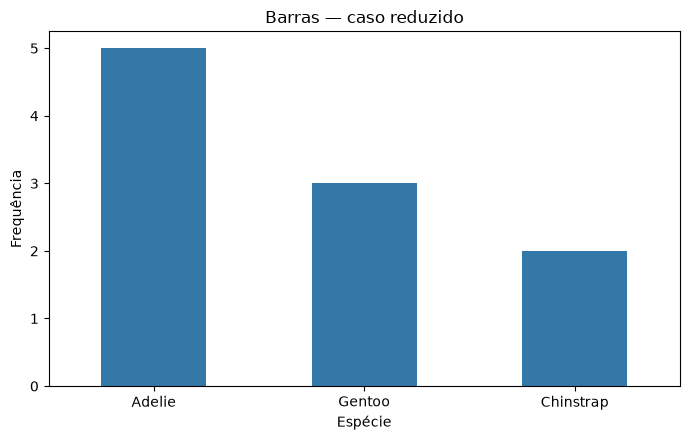

In [10]:
# Representar as frequências reduzidas por espécie.
fig, eixo = plt.subplots(figsize=(7, 4.5))
pd.Series({"Adelie": 5, "Gentoo": 3, "Chinstrap": 2}).plot(
    kind="bar", ax=eixo, color="#3478a8"
)
eixo.set(title="Barras — caso reduzido", xlabel="Espécie", ylabel="Frequência")
eixo.tick_params(axis="x", rotation=0)
fig.tight_layout()
plt.show()


**Figura 1 - Barras do caso reduzido.** As categorias permanecem separadas.


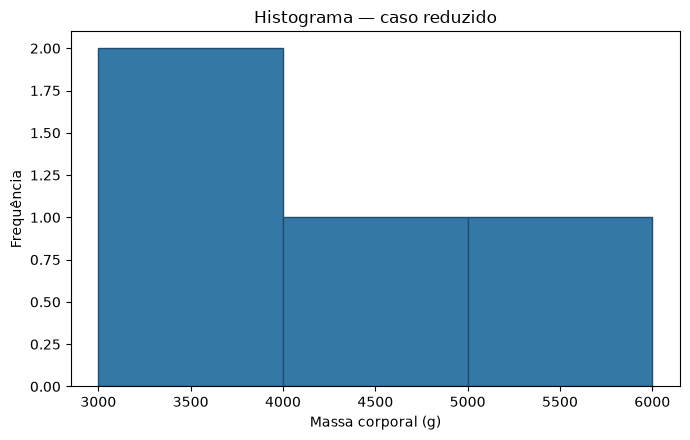

In [11]:
# Representar as massas reduzidas em intervalos contíguos.
fig, eixo = plt.subplots(figsize=(7, 4.5))
eixo.hist(
    [3500, 3750, 4500, 5700],
    bins=[3000, 4000, 5000, 6000],
    color="#3478a8",
    edgecolor="#1f4e70",
)
eixo.set(title="Histograma — caso reduzido", xlabel="Massa corporal (g)", ylabel="Frequência")
fig.tight_layout()
plt.show()


**Figura 2 - Histograma do caso reduzido.** Os intervalos quantitativos são contíguos.


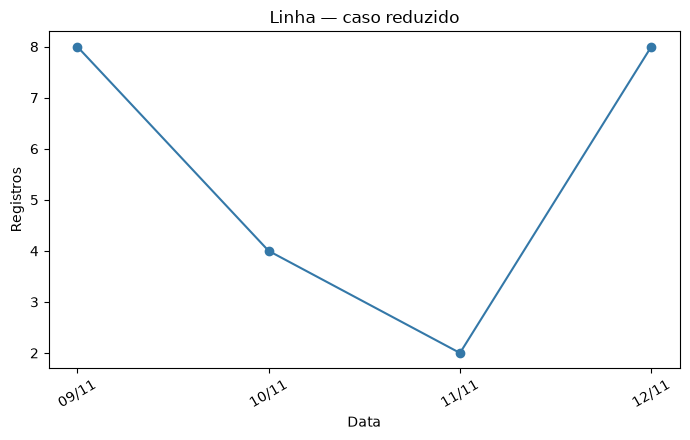

In [12]:
# Representar a sequência temporal reduzida.
datas_reduzidas = pd.to_datetime(["2007-11-09", "2007-11-10", "2007-11-11", "2007-11-12"])
fig, eixo = plt.subplots(figsize=(7, 4.5))
eixo.plot(datas_reduzidas, [8, 4, 2, 8], marker="o", color="#3478a8")
eixo.set(title="Linha — caso reduzido", xlabel="Data", ylabel="Registros")
eixo.set_xticks(datas_reduzidas)
eixo.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
eixo.tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()


**Figura 3 - Linha do caso reduzido.** Os pontos respeitam a ordem das datas.


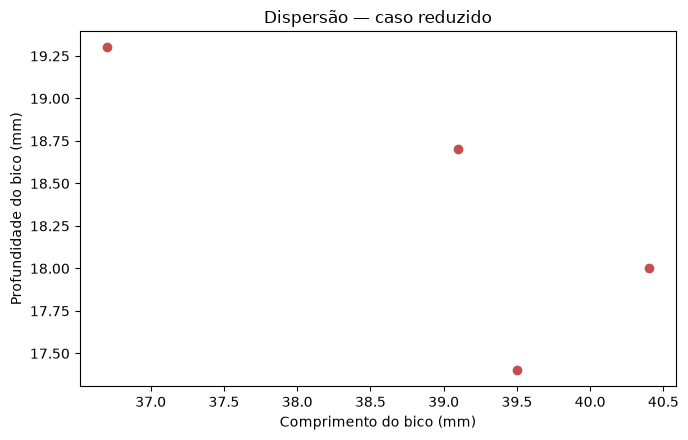

In [13]:
# Representar pares quantitativos sem conectá-los.
fig, eixo = plt.subplots(figsize=(7, 4.5))
eixo.scatter([36.7, 39.1, 39.5, 40.4], [19.3, 18.7, 17.4, 18.0], color="#c84d4d")
eixo.set(
    title="Dispersão — caso reduzido",
    xlabel="Comprimento do bico (mm)",
    ylabel="Profundidade do bico (mm)",
)
fig.tight_layout()
plt.show()


**Figura 4 - Dispersão do caso reduzido.** Os pares quantitativos são preservados sem conexão entre eles.


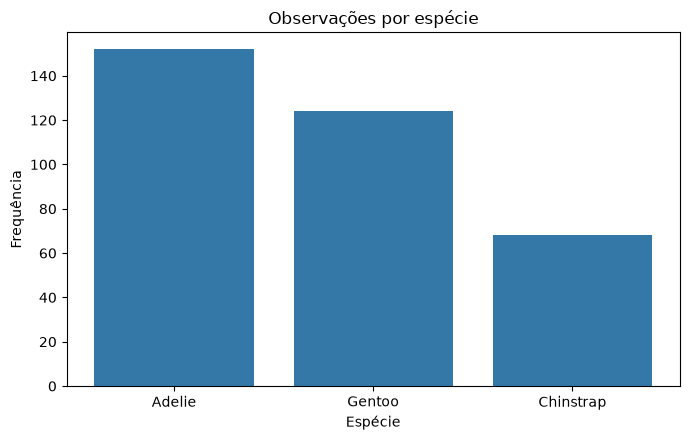

In [14]:
# Representar as observações por espécie.
contagens_species = penguins["Species"].value_counts()
rotulos_species = contagens_species.index.str.split().str[0]
fig, eixo = plt.subplots(figsize=(7, 4.5))
eixo.bar(rotulos_species, contagens_species.values, color="#3478a8")
eixo.set(title="Observações por espécie", xlabel="Espécie", ylabel="Frequência")
fig.tight_layout()
plt.show()


**Figura 5 - Observações por espécie.** As barras descrevem categorias do arquivo Palmer Penguins.


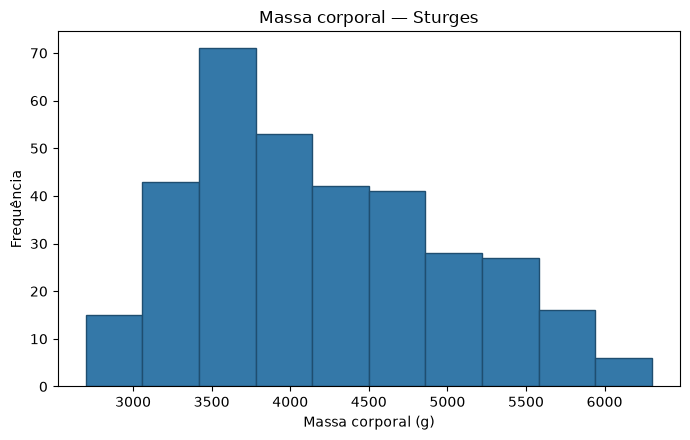

In [15]:
# Representar as massas com classes definidas por Sturges.
fig, eixo = plt.subplots(figsize=(7, 4.5))
eixo.hist(massas_validas, bins="sturges", color="#3478a8", edgecolor="#1f4e70")
eixo.set(title="Massa corporal — Sturges", xlabel="Massa corporal (g)", ylabel="Frequência")
fig.tight_layout()
plt.show()


**Figura 6 - Distribuição da massa corporal por Sturges.** As classes resumem a distribuição das massas válidas.


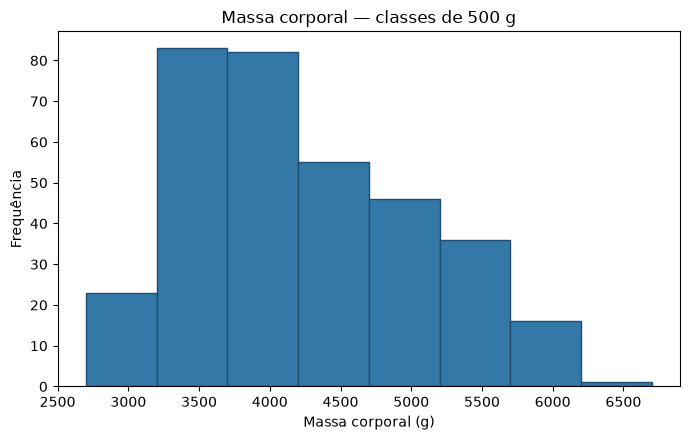

In [16]:
# Representar as massas em classes de 500 g.
fig, eixo = plt.subplots(figsize=(7, 4.5))
eixo.hist(massas_validas, bins=bordas_500, color="#3478a8", edgecolor="#1f4e70")
eixo.set(title="Massa corporal — classes de 500 g", xlabel="Massa corporal (g)", ylabel="Frequência")
fig.tight_layout()
plt.show()


**Figura 7 - Distribuição da massa corporal em classes de 500 g.** A mudança das classes altera o detalhamento visual, mas preserva a amplitude geral.


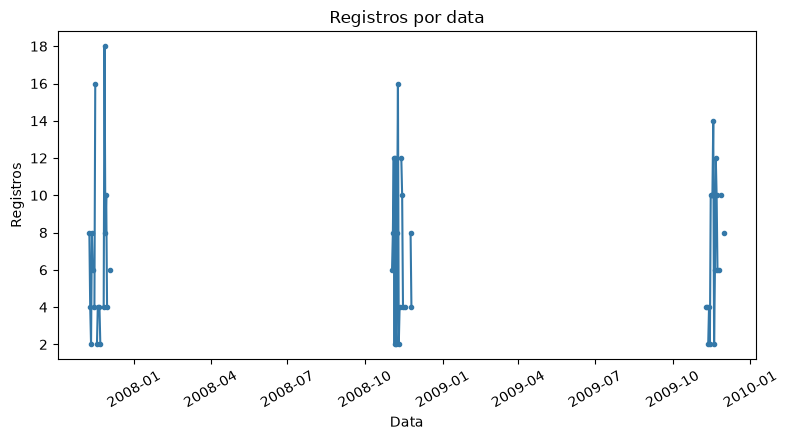

In [17]:
# Representar as contagens por data sem ligar períodos ausentes.
datas = pd.to_datetime(penguins["Date Egg"], format="%Y-%m-%d", errors="coerce")
contagens_data = datas.value_counts().sort_index()
calendario = pd.date_range(contagens_data.index.min(), contagens_data.index.max(), freq="D")
contagens_diarias = contagens_data.reindex(calendario)
fig, eixo = plt.subplots(figsize=(8, 4.5))
eixo.plot(
    contagens_diarias.index,
    contagens_diarias.values,
    marker="o",
    markersize=3,
    color="#3478a8",
)
eixo.set(title="Registros por data", xlabel="Data", ylabel="Registros")
eixo.tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()


**Figura 8 - Registros por data.** A linha organiza as contagens temporalmente e preserva como interrupções os períodos sem observações no arquivo.


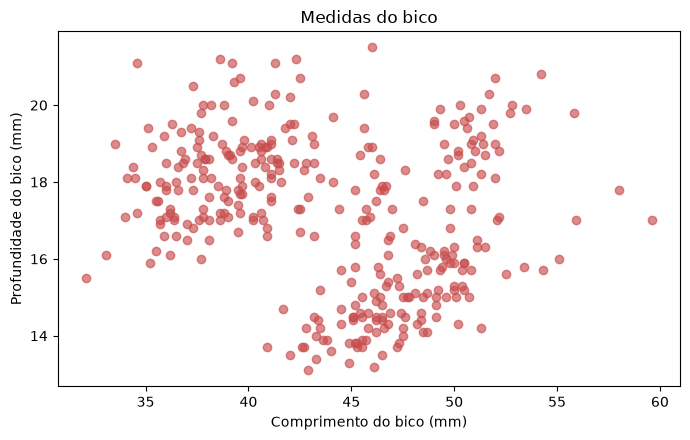

In [18]:
# Representar os pares válidos das medidas do bico.
pares_bico = penguins[["Culmen Length (mm)", "Culmen Depth (mm)"]].dropna()
fig, eixo = plt.subplots(figsize=(7, 4.5))
eixo.scatter(
    pares_bico["Culmen Length (mm)"],
    pares_bico["Culmen Depth (mm)"],
    alpha=0.65,
    color="#c84d4d",
)
eixo.set(
    title="Medidas do bico",
    xlabel="Comprimento do bico (mm)",
    ylabel="Profundidade do bico (mm)",
)
fig.tight_layout()
plt.show()


**Figura 9 - Medidas do bico.** A dispersão mostra associação visual entre duas medidas sem demonstrar causalidade.


### Registro do estudante — ciclo 4

Para cada representação, escreva a pergunta que ela permite responder e um limite de interpretação. Compare especificamente os dois histogramas e indique quais características persistem ou mudam com as classes.

### Resposta

- Barras respondem como as observações se distribuem entre espécies; não estimam a composição das espécies na natureza.
- Histogramas mostram a forma da massa corporal, condicionada às classes escolhidas; Sturges e largura fixa preservam a amplitude geral, mas alteram o detalhamento visual.
- Linha mostra como as contagens se ordenam pelas datas registradas; não representa abundância populacional ao longo do tempo.
- Dispersão permite examinar a associação visual entre comprimento e profundidade do bico; associação não demonstra causalidade.


## Evidência da prática

Entregue as tabelas de frequências, a comparação dos quatro critérios e as cinco representações do conjunto completo. Cada item deverá informar denominador, unidade, critério de agrupamento e uma interpretação breve.


## Síntese da prática

Frequências exigem denominadores explícitos; classes resumem valores ao custo de detalhe; critérios diferentes podem alterar a forma percebida; e cada gráfico incorpora pressupostos sobre separação, continuidade, tempo ou associação. O Palmer Penguins descreve as observações disponíveis e não sustenta, por si só, generalizações para a natureza nem conclusões causais.


## Referências

- BARBETTA, Pedro Alberto; BORNIA, Antonio Cezar; REIS, Marcelo Menezes. *Estatística para cursos de engenharia e informática*. 3. ed. São Paulo: Atlas, 2010.
- FREEDMAN, David; DIACONIS, Persi. On the histogram as a density estimator: $L_2$ theory. *Zeitschrift für Wahrscheinlichkeitstheorie und verwandte Gebiete*, v. 57, p. 453–476, 1981.
- HORST, Allison Marie; HILL, Alison Presmanes; GORMAN, Kristen B. *palmerpenguins: Palmer Archipelago (Antarctica) penguin data*. Versão 0.1.0. Zenodo, 2020. DOI: [10.5281/zenodo.3960218](https://doi.org/10.5281/zenodo.3960218).
- NUMPY DEVELOPERS. *NumPy documentation*. Disponível em: [numpy.org/doc](https://numpy.org/doc/).
- PANDAS DEVELOPMENT TEAM. *pandas documentation*. Disponível em: [pandas.pydata.org/docs](https://pandas.pydata.org/docs/).
- SCOTT, David W. *Multivariate density estimation: theory, practice, and visualization*. 2. ed. Hoboken: Wiley, 2015.
